In [1]:
import warnings

warnings.filterwarnings("ignore")


from pathlib import Path
import anndata as ad

import loompy as lp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import yaml

In [30]:
# tfs_main = pd.read_csv('../../data/human_tfs.csv', index_col=0)
# tfs_main = tfs_main[tfs_main['Is TF?'] == "Yes"]
# tfs_main = tfs_main["HGNC symbol"].tolist()
# for tf in tfs_main:
#     print(f"{tf}")

In [2]:
with open("./config/config.yaml", "r") as file:
    config = yaml.safe_load(file)


In [3]:
tfs = pd.read_csv(config["Input"]["tfs_path"], header=None)[0].tolist()

In [4]:
rna = sc.read_h5ad("../../data/sea_ad/rna_subset.h5ad")

# 2) Pick the symbol column (feature_names vs feature_name)
name_col = 'feature_names' if 'feature_names' in rna.var.columns else 'feature_name'

# 3) Build a clean SYMBOL column; fall back to Ensembl if missing
sym = rna.var[name_col].astype('string').str.strip()
sym = sym.mask(sym.isna() | (sym == ''), rna.var_names)   # fallback to existing ID if empty
rna.var['symbol'] = sym.str.upper()                       # optional: uppercase for consistency

# 4) Set symbols as var_names and make unique
rna.var_names = rna.var['symbol'].to_numpy()
rna.var_names_make_unique()


use_hvg = True
if use_hvg:
    sc.pp.highly_variable_genes(rna, batch_key="donor_id", flavor="seurat")
    hv = rna.var['highly_variable'].astype(bool).to_numpy()   # per-gene boolean
    tf_mask = rna.var_names.isin(tfs)                         # keep all TFs
    mask = hv | tf_mask                                       # union
    rna = rna[:, mask].copy()

# Use the full dataset (no split)
rna_healthy = rna

In [20]:
rna_healthy.var_names

Index(['NFYA', 'NIPAL3', 'ICA1', 'CD38', 'PDK4', 'ARX', 'CALCR', 'MCUB',
       'HOXA11', 'MEOX1',
       ...
       'ENSG00000287621', 'ENSG00000287684', 'ENSG00000287728',
       'ENSG00000287733', 'ENSG00000287950', 'ENSG00000288016',
       'ENSG00000288059', 'ENSG00000288067', 'ENSG00000288075',
       'ENSG00000288088'],
      dtype='object', length=3239)

In [5]:
# motif databases
motif_path = config["Input"]["motif_path"]
tfs_path = config["Input"]["tfs_path"]
tss_ref = config["Input"]["ref_tss"]

# output paths
from pathlib import Path
loom_path = config["Output"]["loom_path"]            # directory for loom inputs
loom_path_output = config["Output"]["loom_path_output"]  # directory for loom outputs
outpath_adj = config["Output"]["outpath_adj"]         # directory for adjacency CSVs
regulons_path = config["Output"]["regulons_path"]     # directory for regulon CSVs

# Ensure directories exist
Path(loom_path).mkdir(parents=True, exist_ok=True)
Path(loom_path_output).mkdir(parents=True, exist_ok=True)
Path(outpath_adj).mkdir(parents=True, exist_ok=True)
Path(regulons_path).mkdir(parents=True, exist_ok=True)

# Main dataset

In [6]:
row_attributes = {
    "Gene": np.array(rna_healthy.var.index),
}
col_attributes = {
    "CellID": np.array(rna_healthy.obs.index),
    "nGene": np.array(np.sum(rna_healthy.X.transpose() > 0, axis=0)).flatten(),
    "nUMI": np.array(np.sum(rna_healthy.X.transpose(), axis=0)).flatten(),
}

from pathlib import Path
loom_in_path = Path(loom_path) / "rna_main.loom"
loom_in_path.parent.mkdir(parents=True, exist_ok=True)
lp.create(str(loom_in_path), rna_healthy.X.transpose(), row_attributes, col_attributes)

In [7]:
from pathlib import Path
from pathlib import Path
import numpy as np
import pandas as pd
import loompy
from collections import defaultdict

loom_in_path = Path(loom_path) / "rna_main.loom"
adj_out_path = Path(outpath_adj) / "main_adj.csv"

# --- Basic bootstrap parameters (reverted) ---
N_RUNS = 20            # number of bootstrap GRN runs
CELL_FRAC = 0.8        # fraction of cells per bootstrap (with replacement)
STAB_THR = 0.1         # keep edges seen in >=10% of runs
WORKERS = 12           # matches original --num_workers
TMP_DIR = Path(outpath_adj) / "_boot"
TMP_DIR.mkdir(parents=True, exist_ok=True)

# Optional consensus outputs (same folder; additive)
consensus_adj_path = Path(outpath_adj) / "main_adj_consensus.csv"
filtered_adj_path  = Path(outpath_adj) / "main_adj_consensus_filt.csv"

# --- Helper: create a bootstrap loom by resampling cells with replacement ---
def make_bootstrap_loom(src_loom, dst_loom, cell_frac, seed):
    with loompy.connect(str(src_loom), 'r') as ds:
        n_cells = ds.shape[1]
        n_take = int(np.ceil(cell_frac * n_cells))
        rng = np.random.default_rng(seed)
        cols = rng.integers(0, n_cells, size=n_take)
        loompy.create(dst_loom, ds[:, :][:, cols], ds.ra, {k: v[cols] for k, v in ds.ca.items()})

# ------------------------------------------------
# Step 1: Global GRN inference (bootstrap consensus)
# ------------------------------------------------
# Build a stability-filtered consensus GRN once; no group-specific GRNs.
if not adj_out_path.exists():
    for r in range(N_RUNS):
        boot_loom = TMP_DIR / f"boot_{r}.loom"
        boot_adj  = TMP_DIR / f"adj_{r}.csv"
        if not boot_adj.exists():
            if not boot_loom.exists():
                make_bootstrap_loom(loom_in_path, str(boot_loom), CELL_FRAC, seed=1000 + r)
            !pyscenic grn {str(boot_loom)} {tfs_path} -o {str(boot_adj)} --num_workers {WORKERS}

    # Aggregate edges across bootstrap runs
    counts = defaultdict(int)
    weights = defaultdict(list)
    for r in range(N_RUNS):
        boot_adj = TMP_DIR / f"adj_{r}.csv"
        if not boot_adj.exists():
            continue
        df = pd.read_csv(boot_adj)
        for _, row in df.iterrows():
            edge = (row['TF'], row['target'])
            counts[edge] += 1
            weights[edge].append(row['importance'])

    recs = []
    for (tf, tg), k in counts.items():
        w = weights[(tf, tg)]
        recs.append({
            'TF': tf,
            'target': tg,
            'n_present': k,
            'stability': k / N_RUNS,
            'importance_mean': float(np.mean(w)),
            'importance_median': float(np.median(w)),
        })
    consensus = pd.DataFrame(recs).sort_values(['stability','importance_median'], ascending=[False, False])
    consensus.to_csv(consensus_adj_path, index=False)

    # Filter by stability and map median importance -> importance (format expected by ctx)
    consensus_filt = (consensus.loc[consensus['stability'] >= STAB_THR, ['TF','target','importance_median']]
                                .rename(columns={'importance_median': 'importance'}))
    consensus_filt.to_csv(filtered_adj_path, index=False)

    # Write filtered consensus to original expected filename
    consensus_filt.to_csv(adj_out_path, index=False)

# ----------------------------------------------
# Step 2: Regulatory motif enrichment (ctx step)
# ----------------------------------------------
reg_out_path = Path(regulons_path) / "main_reg.csv"
if not reg_out_path.exists():
    !pyscenic ctx {str(adj_out_path)} \
        {tss_ref} \
        --annotations_fname {motif_path} \
        --expression_mtx_fname {str(loom_in_path)} \
        --output {str(reg_out_path)} \
        --mask_dropouts \
        --num_workers {WORKERS} > pyscenic_ctx_stdout.txt

# -----------------------------------------
# Step 3: AUCell (regulon activity scoring)
# -----------------------------------------
aucell_csv_path = Path(loom_path_output) / "rna_main_aucell.csv"
if not aucell_csv_path.exists():
    !pyscenic aucell {str(loom_in_path)} \
        {str(reg_out_path)} \
        --output {str(aucell_csv_path)} \
        --num_workers {WORKERS} > pyscenic_aucell_stdout.txt

auc = pd.read_csv(aucell_csv_path)
if "Cell" in auc.columns:
    auc.index = auc["Cell"]
    auc = auc.drop(columns=["Cell"])  # index becomes cell id
auc.to_csv(aucell_csv_path)

/opt/anaconda3/envs/pyscenic/lib/python3.10/site-packages/ctxcore/__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution

2025-11-19 15:19:00,077 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.

2025-11-19 15:19:00,077 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.

2025-11-19 15:19:00,147 - pyscenic.cli.pyscenic - INFO - Inferring regulatory networks.

2025-11-19 15:19:00,147 - pyscenic.cli.pyscenic - INFO - Inferring regulatory networks.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a no

In [ ]:
# Step 1: GRN (Gene Regulatory Network) inference
# ------------------------------------------------
# Checks if the adjacency output file doesn't exist.
# If not, runs the 'pyscenic grn' command to infer the co-expression network
# between transcription factors (TFs) and potential target genes.
# 
# Inputs:
#   - loom_path: the expression matrix in .loom format
#   - tfs_path: list of transcription factors
# Output:
#   - outpath_adj: adjacency matrix file with TF–target relationships
# Options:
#   - --num_workers 10: parallelizes the computation across 10 CPU cores

from pathlib import Path
loom_in_path = Path(loom_path) / "rna_main.loom"
adj_out_path = Path(outpath_adj) / "main_adj.csv"

if not adj_out_path.exists():
    !pyscenic grn {str(loom_in_path)} {tfs_path} -o {str(adj_out_path)} --num_workers 10


# Step 2: Regulatory motif enrichment (ctx step)
# ----------------------------------------------
# Checks if the regulon file (reg.csv) doesn't exist.
# If not, runs 'pyscenic ctx' which refines the GRN by pruning spurious connections.
# It uses motif enrichment analysis (with motif databases) and genomic positions (TSS reference).
# 
# Inputs:
#   - adj.csv: adjacency matrix from the GRN step
#   - tss_ref: transcription start site reference annotation
#   - motif_path: motif annotations for identifying TF binding sites
#   - loom_path: expression matrix (for contextual info)
# Output:
#   - reg.csv: the list of high-confidence regulons (TF → target gene sets)
# Options:
#   - --mask_dropouts: handles zero-inflated single-cell data
#   - --num_workers 10: runs on 10 CPU cores
#   - '> pyscenic_ctx_stdout.txt': logs output to file

reg_out_path = Path(regulons_path) / "main_reg.csv"
if not reg_out_path.exists():
    !pyscenic ctx {str(adj_out_path)} \
        {tss_ref} \
        --annotations_fname {motif_path} \
        --expression_mtx_fname {str(loom_in_path)} \
        --output {str(reg_out_path)} \
        --mask_dropouts \
        --num_workers 10 > pyscenic_ctx_stdout.txt


# Step 3: AUCell (regulon activity scoring)
# -----------------------------------------
# Output AUCell scores as CSV

aucell_csv_path = Path(loom_path_output) / "rna_main_aucell.csv"
if not aucell_csv_path.exists():
    !pyscenic aucell {str(loom_in_path)} \
        {str(reg_out_path)} \
        --output {str(aucell_csv_path)} \
        --num_workers 10 > pyscenic_aucell_stdout.txt

# Read AUCell CSV (cells x regulons with an optional 'Cell' column)
auc = pd.read_csv(aucell_csv_path)
if "Cell" in auc.columns:
    auc.index = auc["Cell"]
    auc = auc.drop(columns=["Cell"])  # make index the cell id

auc.to_csv(aucell_csv_path)

In [24]:
from pathlib import Path
import pandas as pd

# Paths resolved earlier
aucell_csv_path = Path(loom_path_output) / "rna_main_aucell.csv"
adj_out_path = Path(outpath_adj) / "main_adj.csv"
reg_out_path = Path(regulons_path) / "main_reg.csv"

# Read adjacency and regulons tables
auc = pd.read_csv(aucell_csv_path, index_col=0)
adj = pd.read_csv(adj_out_path)
reg = pd.read_csv(reg_out_path)

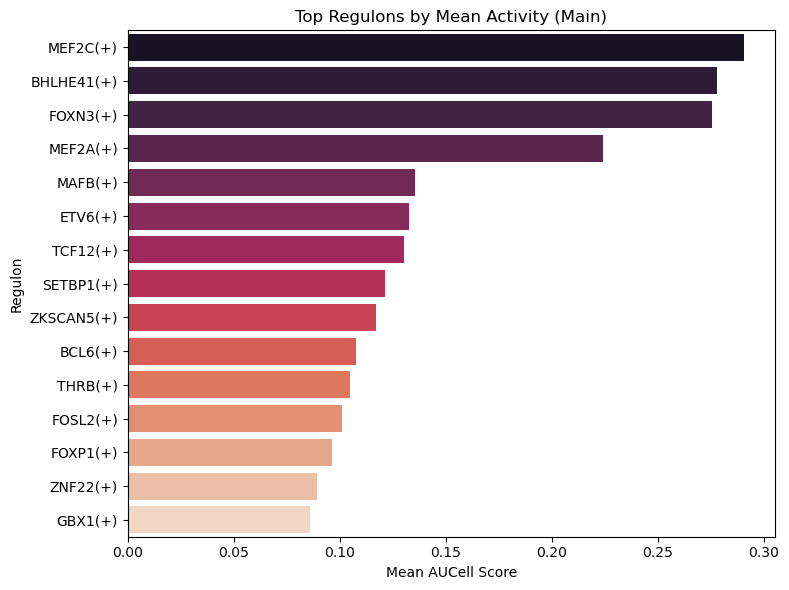

In [8]:
mean_scores = auc.mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=mean_scores.values[:15], y=mean_scores.index[:15], palette="rocket")
plt.xlabel("Mean AUCell Score")
plt.ylabel("Regulon")
plt.title("Top Regulons by Mean Activity (Main)")
plt.tight_layout()
plt.show()

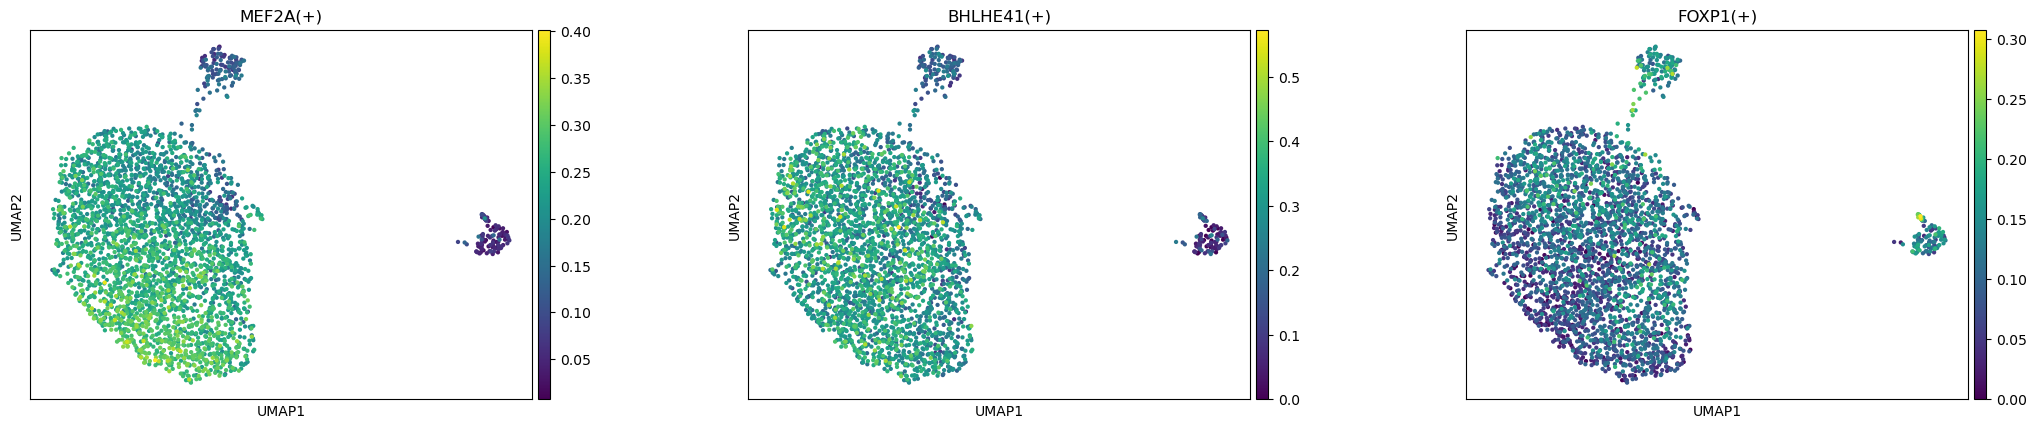

In [9]:
# --- 0) Subset to microglia (keeps names you’re already using) ---
mg_mask = (rna.obs.get('Subclass', pd.Series(index=rna.obs_names)).astype(str).str.lower() == 'microglia') \
       | (rna.obs.get('cell_type', pd.Series(index=rna.obs_names)).astype(str).str.lower().isin(['microglia','microglial cell']))
mg = rna[mg_mask].copy()

# --- 1) Neighbors using the same latent if available (prefer X_scVI) ---
use_rep = 'X_scVI' if 'X_scVI' in mg.obsm_keys() else None

# Try to reuse global params; fall back to sane defaults
n_neighbors = (rna.uns.get('neighbors', {}).get('params', {}) or {}).get('n_neighbors', 15)
umap_params = rna.uns.get('umap', {}).get('params', {}) or {}
min_dist    = umap_params.get('min_dist', 0.3)
spread      = umap_params.get('spread', 1.0)

if use_rep is None:
    # If scVI (or other latent) isn’t present, do a quick PCA on microglia
    sc.pp.highly_variable_genes(mg, n_top_genes=2000, subset=True)
    sc.pp.scale(mg, max_value=10)
    sc.tl.pca(mg, svd_solver='arpack')
    sc.pp.neighbors(mg, n_neighbors=n_neighbors, n_pcs=min(50, mg.obsm.get('X_pca', pd.DataFrame()).shape[1] if 'X_pca' in mg.obsm_keys() else 50))
else:
    sc.pp.neighbors(mg, n_neighbors=n_neighbors, use_rep=use_rep)

# --- 2) Microglia-specific UMAP (fresh embedding) ---
sc.tl.umap(mg, min_dist=min_dist, spread=spread, random_state=0)
mg.uns['default_embedding'] = 'X_umap'  # helps downstream plotting

# --- 3) Align AUCell with microglia cells and store in obsm/obs ---
# Ensure AUCell index is cell IDs
if "Cell" in auc.columns:  # you already handled this above; safe guard
    auc = auc.set_index("Cell")
auc_mg = auc.reindex(mg.obs_names)  # align rows to microglia
mg.obsm['AUCell_main'] = auc_mg

# Also put a few columns into obs for easy scanpy plotting
top_regs = ['MEF2A(+)', 'RUNX2(+)', 'BHLHE41(+)', 'FOXP1(+)']  # change to what you care about
for reg in top_regs:
    if reg in auc_mg.columns:
        mg.obs[reg] = auc_mg[reg]


try:
    import matplotlib.pyplot as plt
    sc.pl.umap(mg, color=[r for r in top_regs if r in mg.obs], color_map='viridis',
               wspace=0.3, show=False)
except Exception as e:
    print(f"(Plotting skipped) {e}")

In [10]:
# === Microglia regulon summaries, plots, and saves ===
import numpy as np
import pandas as pd
from pathlib import Path
import scanpy as sc
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 0) Paths for outputs (adjust if you prefer a different location)
# ------------------------------------------------------------------
out_dir = Path(str(loom_path_output)).joinpath("microglia")
out_dir.mkdir(parents=True, exist_ok=True)
fig_dir = out_dir / "figs"
fig_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------------
# 1) AUCell on microglia: tidy, basic summaries
# ------------------------------------------------------------------
# Ensure AUCell index is cells and aligned to mg
if "Cell" in auc.columns:
    auc = auc.set_index("Cell")
auc_mg = auc.reindex(mg.obs_names)

# optional NA handling (some cells may have been filtered)
auc_mg = auc_mg.fillna(0.0)

# Save the microglia AUCell matrix (per cell x regulon)
auc_mg.to_csv(out_dir / "microglia_aucell.csv")

# Per-regulon summary (mean ± std across microglia)
reg_summary = pd.DataFrame({
    "mean": auc_mg.mean(axis=0),
    "std": auc_mg.std(axis=0),
    "median": auc_mg.median(axis=0),
    "nonzero_frac": (auc_mg > 0).mean(axis=0)
}).sort_values("mean", ascending=False)
reg_summary.to_csv(out_dir / "microglia_regulon_summary.csv")

# ------------------------------------------------------------------
# 2) Put top regulons into mg.obs for easy plotting
# ------------------------------------------------------------------
TOP_K = 30 # how many to visualize on UMAP
top_regs = list(reg_summary.head(TOP_K).index)

for reg in top_regs:
    if reg in auc_mg.columns:
        mg.obs[reg] = auc_mg[reg].astype(float)

# Keep the full AUCell matrix in obsm (already there, but refresh to aligned copy)
mg.obsm['AUCell_main'] = auc_mg

# ------------------------------------------------------------------
# 3) Barplot: top regulons by mean AUCell
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))
reg_summary.head(15)["mean"].iloc[::-1].plot(kind="barh")
plt.xlabel("Mean AUCell Score")
plt.ylabel("Regulon")
plt.title("Top Regulons by Mean Activity (Microglia)")
plt.tight_layout()
plt.savefig(fig_dir / "top_regulons_by_mean_aucell_microglia.png", dpi=200)
plt.close()

# ------------------------------------------------------------------
# 4) UMAP colored by top regulons (microglia-specific embedding)
# ------------------------------------------------------------------
# Plot in batches of up to 6 per figure to keep panels readable
batch = 6
for i in range(0, len(top_regs), batch):
    regs_batch = [r for r in top_regs[i:i+batch] if r in mg.obs]
    if not regs_batch:
        continue
    sc.pl.umap(
        mg, color=regs_batch, color_map="viridis", wspace=0.25,
        ncols=min(3, len(regs_batch)), show=False, s=10
    )
    plt.savefig(fig_dir / f"umap_microglia_aucell_batch_{i//batch+1}.png", bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------------
# 5) (Optional) Per-state averages if you have a label like mg_state/Subclass
# ------------------------------------------------------------------
label_key = "mg_state" if "mg_state" in mg.obs.columns else ("Subclass" if "Subclass" in mg.obs.columns else None)
if label_key is not None:
    state_means = auc_mg.groupby(mg.obs[label_key]).mean()
    state_means.to_csv(out_dir / f"microglia_aucell_by_{label_key}.csv")

# ------------------------------------------------------------------
# 6) (Optional) Correlation of regulon activity with UMAP axes
# ------------------------------------------------------------------
coords = pd.DataFrame(mg.obsm["X_umap"], index=mg.obs_names, columns=["UMAP1","UMAP2"])
corr_umap1 = auc_mg.corrwith(coords["UMAP1"]).sort_values(ascending=False)
corr_umap2 = auc_mg.corrwith(coords["UMAP2"]).sort_values(ascending=False)
corr_df = pd.DataFrame({"corr_UMAP1": corr_umap1, "corr_UMAP2": corr_umap2}).sort_values("corr_UMAP1", ascending=False)
corr_df.to_csv(out_dir / "microglia_regulon_umap_correlations.csv")

# ------------------------------------------------------------------
# 7) Save the microglia AnnData with embedding + AUCell attached
# ------------------------------------------------------------------
mg.write(out_dir / "microglia_with_umap_and_aucell.h5ad")

print(f"Saved:\n- {out_dir/'microglia_aucell.csv'}\n- {out_dir/'microglia_regulon_summary.csv'}"
      f"\n- {fig_dir/'top_regulons_by_mean_aucell_microglia.png'}"
      f"\n- {fig_dir}/*umap_microglia_aucell_batch_*.png"
      f"\n- {out_dir/'microglia_regulon_umap_correlations.csv'}"
      f"\n- {out_dir/'microglia_with_umap_and_aucell.h5ad'}")


Saved:
- ../../code/pyscenic/outputs/microglia/microglia_aucell.csv
- ../../code/pyscenic/outputs/microglia/microglia_regulon_summary.csv
- ../../code/pyscenic/outputs/microglia/figs/top_regulons_by_mean_aucell_microglia.png
- ../../code/pyscenic/outputs/microglia/figs/*umap_microglia_aucell_batch_*.png
- ../../code/pyscenic/outputs/microglia/microglia_regulon_umap_correlations.csv
- ../../code/pyscenic/outputs/microglia/microglia_with_umap_and_aucell.h5ad


In [11]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal

# ---------- 1. Basic inputs ----------
# mg: AnnData with microglia only
# mg.obsm['AUCell_main']: cells x regulons AUCell scores

# Column with Braak info, formatted like "Braak 0", "Braak III", "Braak VI", etc.
braak_col = next(c for c in ['Braak stage', 'Braak', 'braak', 'braak_stage'] if c in mg.obs.columns)

# Column with donor / individual ID
donor_col = next(c for c in ['donor_id', 'Donor', 'individual', 'sample_id'] if c in mg.obs.columns)

# ---------- 2. Parse Braak to integer 0..6 ----------
roman_map = {'0':0, 'I':1, 'II':2, 'III':3, 'IV':4, 'V':5, 'VI':6}

def parse_braak(x: str):
    x = str(x).strip()
    x = x.replace('Braak', '').strip()   # drop "Braak" prefix if present
    x = x.upper()
    return roman_map.get(x, np.nan)

mg.obs['Braak_int'] = mg.obs[braak_col].map(parse_braak)

# keep cells with Braak + donor defined
keep = mg.obs['Braak_int'].notna() & mg.obs[donor_col].notna()
mg_sub = mg[keep].copy()

# ---------- 3. Pseudobulk AUCell: mean per (donor, Braak) ----------
auc = pd.DataFrame(
    mg_sub.obsm['AUCell_main'],
    index=mg_sub.obs_names,
    columns=mg_sub.obsm['AUCell_main'].columns
)

meta = mg_sub.obs[[donor_col, 'Braak_int']]

pb = (
    pd.concat([meta, auc], axis=1)
      .groupby([donor_col, 'Braak_int'])
      .mean()
      .reset_index()
)

pb = pb.rename(columns={'Braak_int': 'Braak'})
stages = sorted(pb['Braak'].unique())

# ---------- 4. Kruskal–Wallis across Braak stages ----------
def bh_fdr(pvals: np.ndarray):
    p = np.asarray(pvals, float)
    n = p.size
    order = np.argsort(p)
    ranked = np.empty(n)
    ranked[order] = np.minimum.accumulate((p[order] * n / (np.arange(n) + 1))[::-1])[::-1]
    return np.clip(ranked, 0.0, 1.0)

results = []
regulon_cols = [c for c in pb.columns if c not in [donor_col, 'Braak']]

for reg in regulon_cols:
    # values per stage (on pseudobulked donors)
    arrays = [pb.loc[pb['Braak'] == s, reg].dropna().values for s in stages]

    # require at least 2 Braak stages with >= 2 donors each
    if sum(len(a) >= 2 for a in arrays) < 2:
        continue

    try:
        H, p = kruskal(*arrays)
    except ValueError:
        continue

    means = [float(a.mean()) if len(a) else np.nan for a in arrays]

    entry = {
        'regulon': reg,
        'H': H,
        'pval': p,
    }

    for s, m in zip(stages, means):
        entry[f'mean_Braak_{s}'] = m

    # effect size: max difference between any two stages
    if len(means) > 1:
        entry['max_delta'] = float(np.nanmax(means) - np.nanmin(means))
    else:
        entry['max_delta'] = np.nan

    # specific VI - 0 contrast if both exist
    if 0 in stages and 6 in stages:
        m0 = entry.get('mean_Braak_0', np.nan)
        m6 = entry.get('mean_Braak_6', np.nan)
        entry['delta_6_0'] = m6 - m0

    results.append(entry)

res = pd.DataFrame(results)

if not res.empty:
    res['qval'] = bh_fdr(res['pval'].values)
    res = res.sort_values(['qval', 'max_delta'], ascending=[True, False]).reset_index(drop=True)

res


,regulon,H,pval,mean_Braak_0,mean_Braak_3,mean_Braak_4,mean_Braak_5,mean_Braak_6,max_delta,delta_6_0,qval
0,MAFB(+),10.348148,0.034954,0.111850,0.148803,0.092036,0.135088,0.223373,0.131338,0.111524,0.555320
1,ETV6(+),8.493122,0.075096,0.221470,0.173418,0.124654,0.126975,0.158146,0.096816,-0.063324,0.555320
2,FOXN3(+),7.956790,0.093174,0.226826,0.203494,0.282013,0.269624,0.249376,0.078520,0.022549,0.555320
3,MEF2C(+),6.852028,0.143918,0.243711,0.226955,0.298861,0.282080,0.272001,0.071906,0.028291,0.555320
4,MEF2A(+),6.211640,0.183891,0.200433,0.175159,0.233346,0.219129,0.205991,0.058187,0.005558,0.555320
...,...,...,...,...,...,...,...,...,...,...,...
255,BATF3(+),0.582716,0.964965,0.001711,0.002076,0.002138,0.002305,0.001880,0.000594,0.000169,0.980042
256,NFKB2(+),0.532451,0.970266,0.016948,0.021693,0.017884,0.017578,0.017914,0.004746,0.000967,0.981592
257,ZEB1(+),0.419753,0.980828,0.009124,0.009729,0.009865,0.009964,0.010372,0.001248,0.001248,0.988431
258,STAT2(+),0.222928,0.994231,0.041899,0.045981,0.042807,0.042030,0.043031,0.004083,0.001132,0.998070


In [12]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# ---------- 1. Basic inputs ----------
braak_col = next(c for c in ['Braak stage', 'Braak', 'braak', 'braak_stage'] if c in mg.obs.columns)
donor_col = next(c for c in ['donor_id', 'Donor', 'individual', 'sample_id'] if c in mg.obs.columns)

# ---------- 2. Parse Braak to integer 0..6 ----------
roman_map = {'0':0, 'I':1, 'II':2, 'III':3, 'IV':4, 'V':5, 'VI':6}

def parse_braak(x: str):
    x = str(x).strip()
    x = x.replace('Braak', '').strip()
    x = x.upper()
    return roman_map.get(x, np.nan)

mg.obs['Braak_int'] = mg.obs[braak_col].map(parse_braak)

# cells with complete donor + Braak data
keep = mg.obs['Braak_int'].notna() & mg.obs[donor_col].notna()
mg_sub = mg[keep].copy()

# ---------- 3. Pseudobulk AUCell per (donor, Braak) ----------
auc = pd.DataFrame(
    mg_sub.obsm['AUCell_main'],
    index=mg_sub.obs_names,
    columns=mg_sub.obsm['AUCell_main'].columns
)

meta = mg_sub.obs[[donor_col, 'Braak_int']]

pb = (
    pd.concat([meta, auc], axis=1)
      .groupby([donor_col, 'Braak_int'])
      .mean()
      .reset_index()
)

pb = pb.rename(columns={'Braak_int': 'Braak'})
stages = sorted(pb['Braak'].unique())

# ---------- 4. Spearman correlation with Braak ----------
def bh_fdr(pvals: np.ndarray):
    p = np.asarray(pvals, float)
    n = p.size
    order = np.argsort(p)
    ranked = np.empty(n)
    ranked[order] = np.minimum.accumulate((p[order] * n / (np.arange(n) + 1))[::-1])[::-1]
    return np.clip(ranked, 0.0, 1.0)

results = []
regulon_cols = [c for c in pb.columns if c not in [donor_col, 'Braak']]

for reg in regulon_cols:
    
    x = pb['Braak'].values
    y = pb[reg].values
    
    # need at least 3 donors with varying Braak values
    if len(np.unique(x)) < 3:
        continue
    
    # Spearman correlation
    rho, p = spearmanr(x, y, nan_policy='omit')
    
    entry = {
        'regulon': reg,
        'rho': rho,
        'pval': p
    }
    
    # mean AUCell per Braak stage
    means = []
    for s in stages:
        val = pb.loc[pb['Braak'] == s, reg].mean()
        entry[f'mean_Braak_{s}'] = float(val)
        means.append(val)
    
    # effect sizes
    means = np.array(means, float)
    entry['max_delta'] = np.nanmax(means) - np.nanmin(means)
    
    if 0 in stages and 6 in stages:
        entry['delta_6_0'] = entry[f'mean_Braak_6'] - entry[f'mean_Braak_0']
    
    results.append(entry)

res = pd.DataFrame(results)

if not res.empty:
    res['qval'] = bh_fdr(res['pval'].values)
    res = res.sort_values(['qval', 'rho'], ascending=[True, False]).reset_index(drop=True)

res

,regulon,rho,pval,mean_Braak_0,mean_Braak_3,mean_Braak_4,mean_Braak_5,mean_Braak_6,max_delta,delta_6_0,qval
0,YY1(+),0.569821,0.001917,0.034621,0.041252,0.041861,0.048090,0.044730,0.013469,0.010109,0.249273
1,POU6F1(+),-0.579419,0.001539,0.008820,0.007938,0.008309,0.006764,0.005814,0.003006,-0.003006,0.249273
2,TCF7L2(+),-0.514790,0.006004,0.018778,0.027595,0.017384,0.014366,0.014341,0.013255,-0.004438,0.260190
3,NR2C1(+),-0.517429,0.005709,0.005316,0.005371,0.004855,0.003289,0.002116,0.003255,-0.003200,0.260190
4,TFAP4(+),-0.528228,0.004623,0.009719,0.004674,0.007166,0.004507,0.003785,0.005934,-0.005934,0.260190
...,...,...,...,...,...,...,...,...,...,...,...
255,EGR3(+),-0.040633,0.840521,0.006473,0.012101,0.007909,0.007447,0.006455,0.005645,-0.000018,0.989891
256,RFX3(+),-0.041593,0.836803,0.027416,0.028729,0.037789,0.035581,0.028194,0.010373,0.000778,0.989891
257,THAP11(+),-0.041913,0.835564,0.007620,0.009075,0.009583,0.008734,0.008727,0.001964,0.001108,0.989891
258,ELK3(+),-0.042233,0.834326,0.054294,0.052828,0.064242,0.059028,0.053711,0.011414,-0.000582,0.989891
